---
## Task 1 — Synthetic Data Generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Student ID & Seed
student_id = "R00277319"
a = int(student_id[-1])   # last digit  → 9
b = int(student_id[-2])   # second-last → 1
if a == 0: a = 5          # replace 0 with 5
if b == 0: b = 5

calc_seed = 100 + 10*a + b   # 191
np.random.seed(calc_seed)

print(f"Student ID: {student_id}  →  a={a}, b={b}, seed={calc_seed}")


Student ID: R00277319  →  a=9, b=1, seed=191


In [2]:
# Dataset A: Gaussian Clusters
center1 = [-4 - 0.1*a,  4 + 0.1*b]   # (-4.9,  4.1)
center2 = [0,           -4 - 0.1*a]   # (  0,  -4.9)
center3 = [4 + 0.1*b,   4         ]   # ( 4.1,  4.0)

g1 = np.random.normal(loc=center1, scale=1.0, size=(40, 2))
g2 = np.random.normal(loc=center2, scale=1.0, size=(40, 2))
g3 = np.random.normal(loc=center3, scale=1.0, size=(40, 2))

dataset_a = np.vstack((g1, g2, g3))   # 120 × 2
print(f"Dataset A shape: {dataset_a.shape}")


Dataset A shape: (120, 2)


In [3]:
#Dataset B: Ring + Blob + Noise
# Ring (70 pts): angle uniform [0, 2π], radius = 4.5 + ε, ε ~ N(0, 0.25²)
theta     = np.random.uniform(0, 2*np.pi, 70)
eps_ring  = np.random.normal(0, 0.25, 70)
r         = 4.5 + eps_ring
ring      = np.column_stack((r * np.cos(theta), r * np.sin(theta)))

# Blob (30 pts): centre (5+0.1a, 0), variance=0.5 → std=√0.5
blob_center = [5 + 0.1*a, 0]   # (5.9, 0)
blob        = np.random.normal(loc=blob_center, scale=np.sqrt(0.5), size=(30, 2))

# Noise (20 pts): uniform over [-7,7]×[-7,7]
noise_pts = np.random.uniform(-7, 7, (20, 2))

dataset_b = np.vstack((ring, blob, noise_pts))   # 120 × 2
print(f"Dataset B shape: {dataset_b.shape}")


Dataset B shape: (120, 2)


In [4]:
#Summary Statistics
def print_stats(name, data):
    print(f"\n{name}:")
    print(f"  X — mean={np.mean(data[:,0]):.4f}, std={np.std(data[:,0]):.4f}")
    print(f"  Y — mean={np.mean(data[:,1]):.4f}, std={np.std(data[:,1]):.4f}")

print_stats("Dataset A", dataset_a)
print_stats("Dataset B", dataset_b)



Dataset A:
  X — mean=-0.3458, std=3.8049
  Y — mean=0.9705, std=4.3307

Dataset B:
  X — mean=1.6331, std=3.7821
  Y — mean=0.2037, std=2.9183


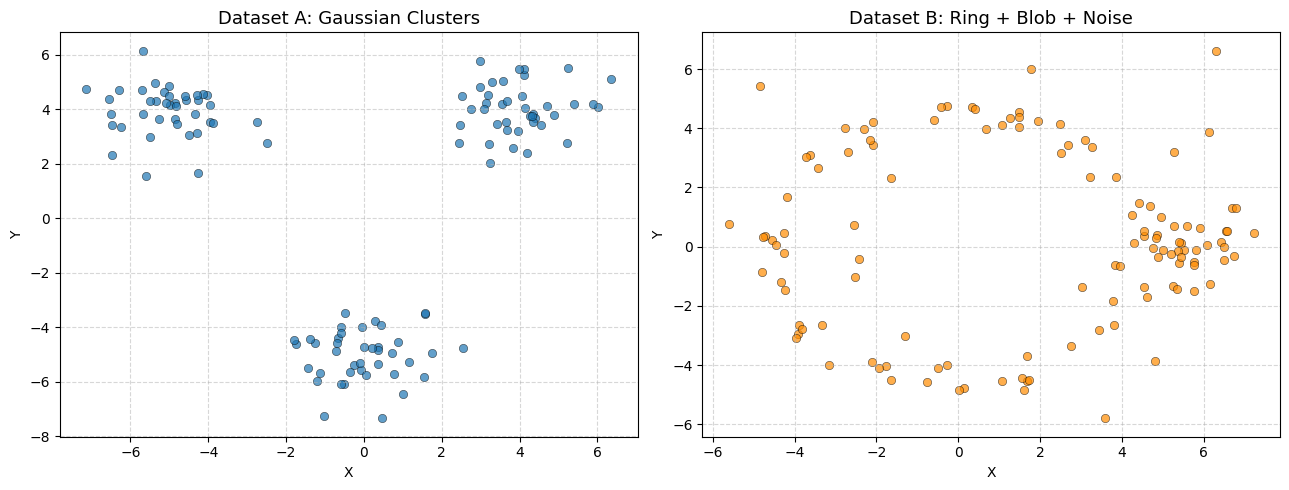

In [5]:
#Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(dataset_a[:, 0], dataset_a[:, 1], alpha=0.7, edgecolors='k', linewidths=0.4)
axes[0].set_title("Dataset A: Gaussian Clusters", fontsize=13)
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(dataset_b[:, 0], dataset_b[:, 1], color='darkorange', alpha=0.7, edgecolors='k', linewidths=0.4)
axes[1].set_title("Dataset B: Ring + Blob + Noise", fontsize=13)
axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("task1_scatter.png", dpi=120)
plt.show()


---
## Task 2 — Manual Prototype Adjustment Clustering

**Algorithm summary:**
- **Initialisation:** First centroid = point with minimum x+y. Each subsequent centroid = point farthest from all already-chosen centroids (Maximin rule).
- **Update rule (online):** For each point (xᵢ, yᵢ) assigned to centroid (u, v):
  - if xᵢ > u → u += α; if xᵢ < u → u -= α (similarly for y)
- **Empty cluster handling:** Move centroid by a random offset ~ U(-0.5, 0.5).
- **SSE** computed after all updates in each epoch.


In [6]:
def manual_prototype(data, K, alpha=0.05, epochs=200):
    """
    Manual prototype-adjustment clustering.

    Parameters
    ----------
    data   : ndarray (n, 2)
    K      : number of clusters
    alpha  : learning rate
    epochs : number of passes over the data

    Returns
    -------
    centroids           : final centroid positions (K, 2)
    assignments         : cluster index for each point (n,)
    sse_history         : SSE per epoch (list of length `epochs`)
    centroid_snapshots  : centroid positions at epoch 0, 50, 100, 150, 200
    """
    np.random.seed(calc_seed)   # reproducibility for empty-cluster resets
    n = data.shape[0]

    # Initialisation
    sums = data[:, 0] + data[:, 1]
    centroids = [data[np.argmin(sums)].copy().astype(float)]

    for _ in range(K - 1):
        min_dists = np.array([
            min(np.sqrt(np.sum((data[i] - c)**2)) for c in centroids)
            for i in range(n)
        ])
        centroids.append(data[np.argmax(min_dists)].copy().astype(float))

    centroids = np.array(centroids, dtype=float)
    sse_history = []
    centroid_snapshots = [centroids.copy()]  # snapshot at epoch 0

    for epoch in range(epochs):
        # Online update: one point at a time
        for i in range(n):
            xi, yi = data[i]
            dists  = np.sqrt(np.sum((centroids - data[i])**2, axis=1))
            k_idx  = int(np.argmin(dists))

            # Directional update rule
            if   xi > centroids[k_idx, 0]: centroids[k_idx, 0] += alpha
            elif xi < centroids[k_idx, 0]: centroids[k_idx, 0] -= alpha
            if   yi > centroids[k_idx, 1]: centroids[k_idx, 1] += alpha
            elif yi < centroids[k_idx, 1]: centroids[k_idx, 1] -= alpha

        #Final assignment for this epoch
        assignments = np.array([
            int(np.argmin(np.sqrt(np.sum((centroids - data[i])**2, axis=1))))
            for i in range(n)
        ])

        #Handle empty clusters
        for k in range(K):
            if np.sum(assignments == k) == 0:
                centroids[k, 0] += np.random.uniform(-0.5, 0.5)
                centroids[k, 1] += np.random.uniform(-0.5, 0.5)

        #SSE using final centroid positions
        sse = float(sum(
            np.sum((data[i] - centroids[assignments[i]])**2)
            for i in range(n)
        ))
        sse_history.append(sse)

        if (epoch + 1) % 50 == 0:
            centroid_snapshots.append(centroids.copy())

    return centroids, assignments, sse_history, centroid_snapshots


# Run for α = 0.05 (primary)
centroids_a, assign_a, sse_a, csnap_a = manual_prototype(dataset_a, K=3, alpha=0.05)
centroids_b, assign_b, sse_b, csnap_b = manual_prototype(dataset_b, K=2, alpha=0.05)

print("Dataset A — Final centroids:")
for k, c in enumerate(centroids_a):
    print(f"  Centroid {k+1}: ({c[0]:.4f}, {c[1]:.4f})")

print("\nDataset B — Final centroids:")
for k, c in enumerate(centroids_b):
    print(f"  Centroid {k+1}: ({c[0]:.4f}, {c[1]:.4f})")

print(f"\nFinal SSE — A: {sse_a[-1]:.2f}   B: {sse_b[-1]:.2f}")


Dataset A — Final centroids:
  Centroid 1: (-0.1173, -4.8555)
  Centroid 2: (3.9575, 4.0181)
  Centroid 3: (-4.9414, 4.0382)

Dataset B — Final centroids:
  Centroid 1: (-2.5701, 0.0083)
  Centroid 2: (5.2964, 0.0204)

Final SSE — A: 215.39   B: 1429.79


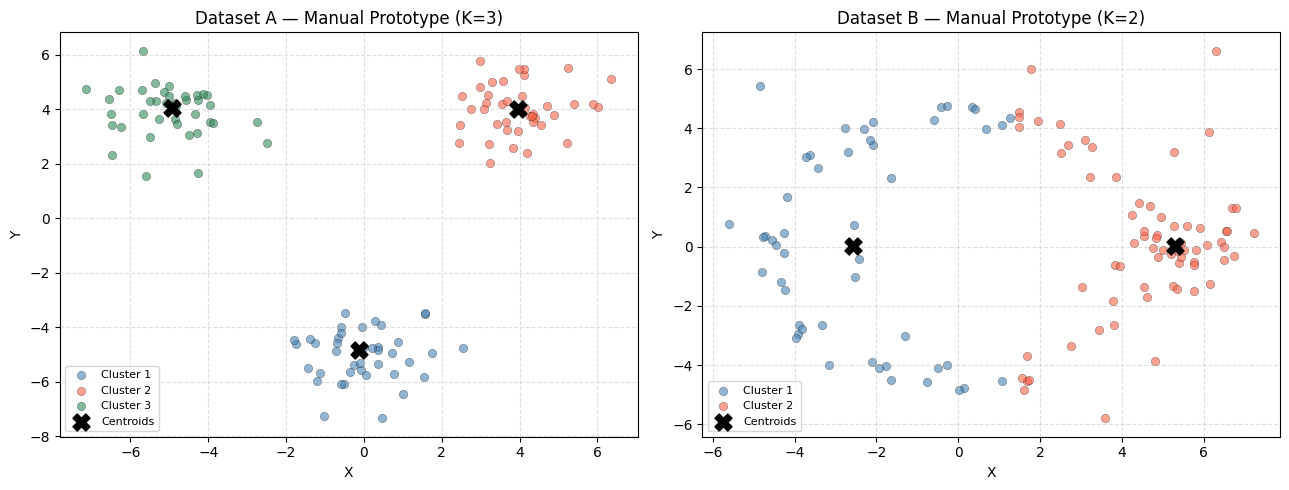

In [7]:
#Plot 1: Final Clustering with Centroids
colors = ['steelblue', 'tomato', 'seagreen', 'orchid']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, labels, cents, title in [
    (axes[0], dataset_a, assign_a, centroids_a, "Dataset A — Manual Prototype (K=3)"),
    (axes[1], dataset_b, assign_b, centroids_b, "Dataset B — Manual Prototype (K=2)")
]:
    for k in range(cents.shape[0]):
        mask = labels == k
        ax.scatter(data[mask, 0], data[mask, 1], color=colors[k],
                   alpha=0.6, edgecolors='k', linewidths=0.3, label=f'Cluster {k+1}')
    ax.scatter(cents[:, 0], cents[:, 1], c='black', marker='X',
               s=150, zorder=5, label='Centroids')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("task2_clusters.png", dpi=120)
plt.show()


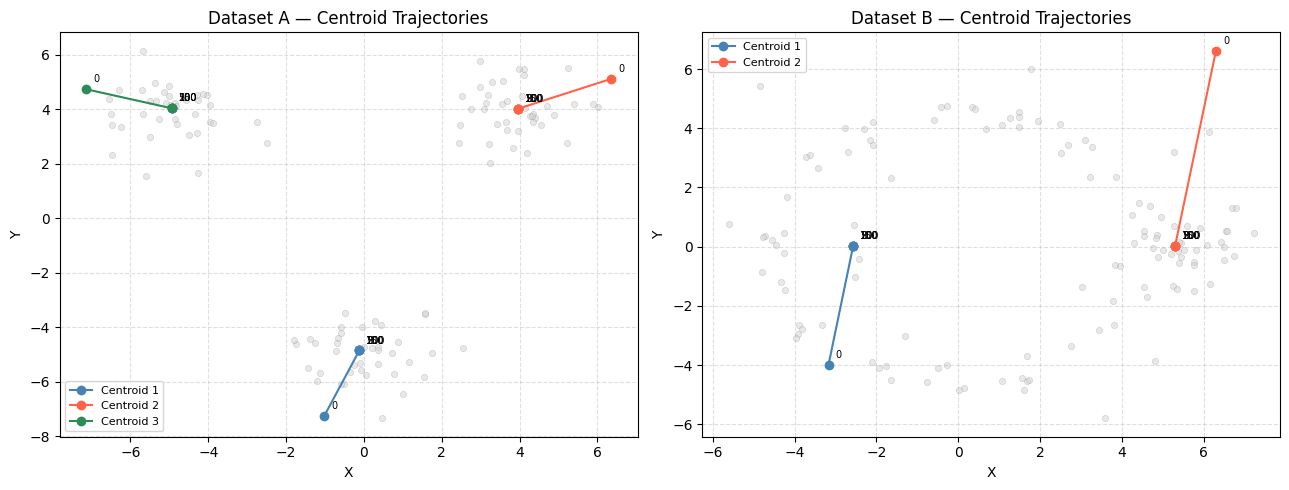

In [8]:
#Plot 2: Centroid Positions Every 50 Epochs

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, snaps, title in [
    (axes[0], dataset_a, csnap_a, "Dataset A — Centroid Trajectories"),
    (axes[1], dataset_b, csnap_b, "Dataset B — Centroid Trajectories")
]:
    ax.scatter(data[:, 0], data[:, 1], color='lightgrey', edgecolors='grey', linewidths=0.3, alpha=0.5, s=20)
    for k in range(snaps[0].shape[0]):
        xs = [s[k, 0] for s in snaps]
        ys = [s[k, 1] for s in snaps]
        ax.plot(xs, ys, '-o', color=colors[k], linewidth=1.5, markersize=6, label=f'Centroid {k+1}')
        for ep, x, y in zip(epoch_labels, xs, ys):
            ax.annotate(str(ep), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("task2_centroid_paths.png", dpi=120)
plt.show()


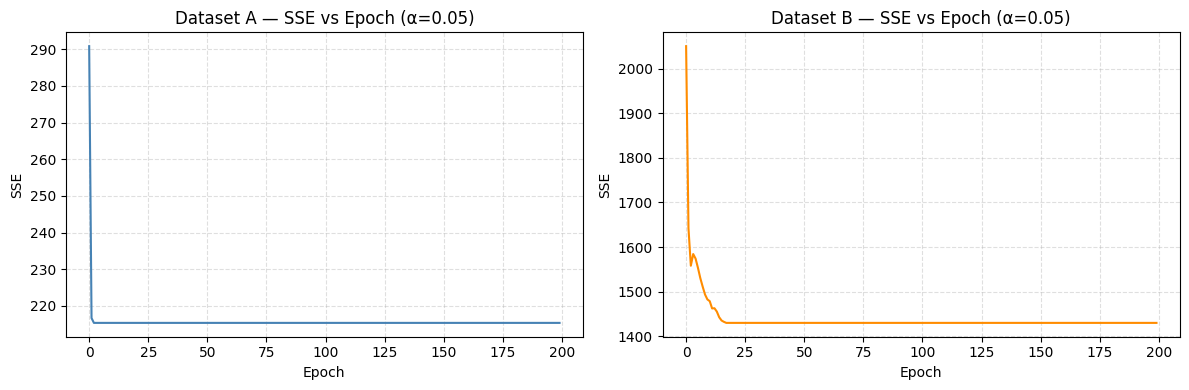

In [9]:
#Plot 3: SSE vs Epoch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sse_a, color='steelblue', linewidth=1.5)
axes[0].set_title("Dataset A — SSE vs Epoch (α=0.05)", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("SSE")
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(sse_b, color='darkorange', linewidth=1.5)
axes[1].set_title("Dataset B — SSE vs Epoch (α=0.05)", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("SSE")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("task2_sse.png", dpi=120)
plt.show()


### Learning Rate Comparison (α = 0.01, 0.05, 0.2)

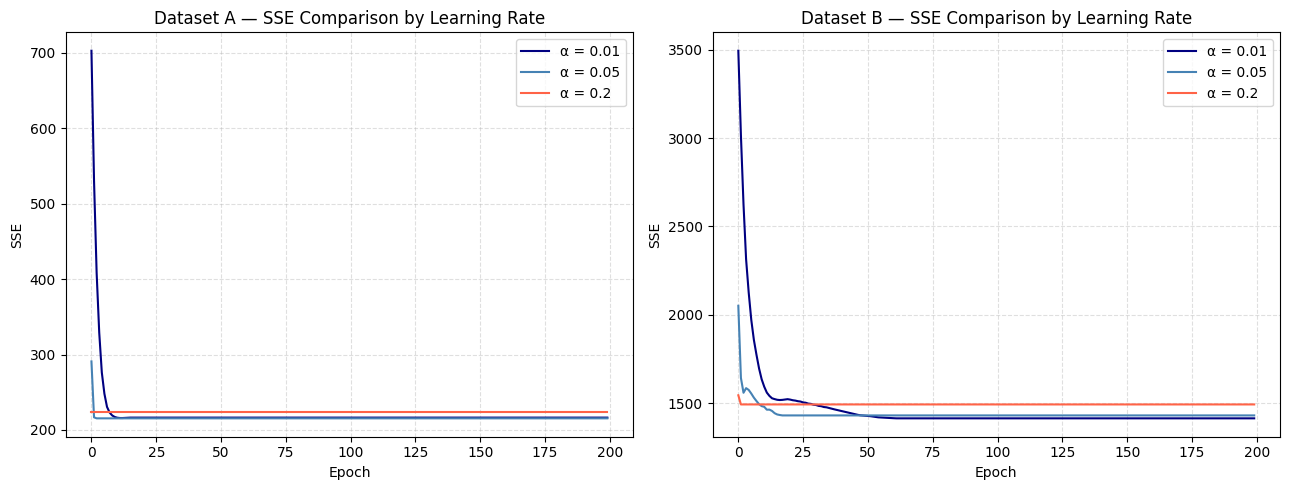

α=0.01  |  Final SSE A: 216.35   Final SSE B: 1413.26
α=0.05  |  Final SSE A: 215.39   Final SSE B: 1429.79
α=0.2  |  Final SSE A: 223.67   Final SSE B: 1491.93


In [10]:
# Run for each learning rate
lrs = [0.01, 0.05, 0.2]
sse_lr_a = {}
sse_lr_b = {}

for lr in lrs:
    _, _, s_a, _ = manual_prototype(dataset_a, K=3, alpha=lr)
    sse_lr_a[lr] = s_a
    _, _, s_b, _ = manual_prototype(dataset_b, K=2, alpha=lr)
    sse_lr_b[lr] = s_b

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lr_colors = ['navy', 'steelblue', 'tomato']

for ax, sse_dict, title in [
    (axes[0], sse_lr_a, "Dataset A — SSE Comparison by Learning Rate"),
    (axes[1], sse_lr_b, "Dataset B — SSE Comparison by Learning Rate")
]:
    for lr, col in zip(lrs, lr_colors):
        ax.plot(sse_dict[lr], color=col, linewidth=1.5, label=f'α = {lr}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch"); ax.set_ylabel("SSE")
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("task2_lr_comparison.png", dpi=120)
plt.show()

for lr in lrs:
    print(f"α={lr}  |  Final SSE A: {sse_lr_a[lr][-1]:.2f}   Final SSE B: {sse_lr_b[lr][-1]:.2f}")


---
## Task 3 — DBSCAN

DBSCAN is implemented from scratch using Euclidean distance and minPts = 4.  
The value of ε is selected from the "elbow" of the sorted 4-nearest-neighbour distance curve.


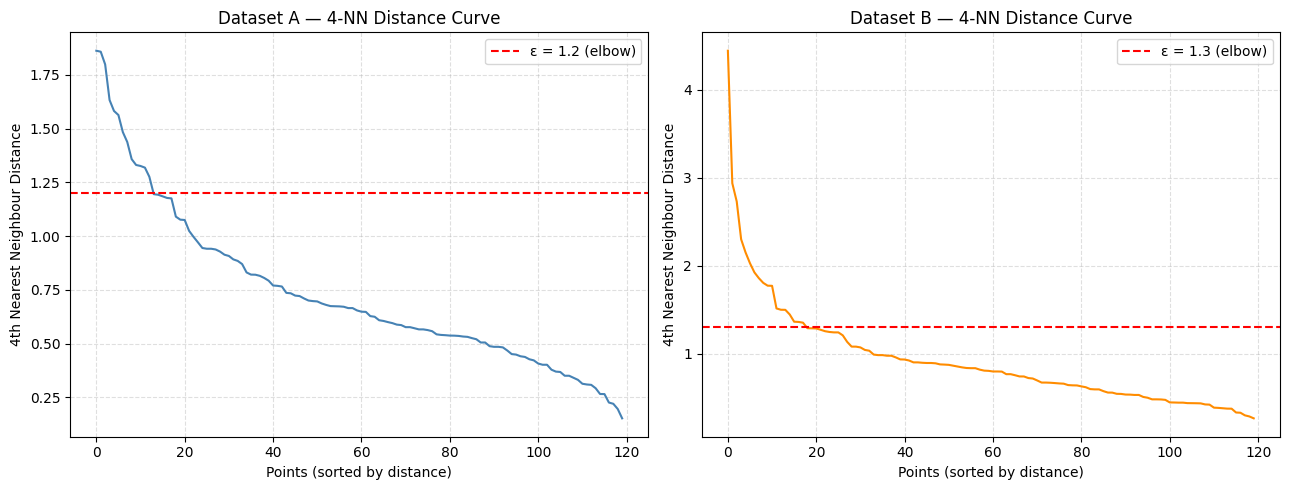

Selected ε:  Dataset A → 1.2   |   Dataset B → 1.3


In [11]:
# 4-NN Distance Computation
def compute_4nn_distances(data, k=4):
    """
    For each point, compute the distance to its k-th nearest neighbour.
    Returns distances sorted in descending order (for elbow plot).
    """
    n = data.shape[0]
    kd = []
    for i in range(n):
        d = np.sqrt(np.sum((data - data[i])**2, axis=1))
        d[i] = np.inf         # exclude self
        kd.append(np.sort(d)[k - 1])   # k-th nearest neighbour distance
    return np.sort(kd)[::-1]  # descending for elbow visualisation

kd_a = compute_4nn_distances(dataset_a, k=4)
kd_b = compute_4nn_distances(dataset_b, k=4)

#4-NN Elbow Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dataset A
axes[0].plot(kd_a, color='steelblue', linewidth=1.5)
axes[0].axhline(y=1.2, color='red', linestyle='--', label='ε = 1.2 (elbow)')
axes[0].set_title("Dataset A — 4-NN Distance Curve", fontsize=12)
axes[0].set_xlabel("Points (sorted by distance)")
axes[0].set_ylabel("4th Nearest Neighbour Distance")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)

# Dataset B
axes[1].plot(kd_b, color='darkorange', linewidth=1.5)
axes[1].axhline(y=1.3, color='red', linestyle='--', label='ε = 1.3 (elbow)')
axes[1].set_title("Dataset B — 4-NN Distance Curve", fontsize=12)
axes[1].set_xlabel("Points (sorted by distance)")
axes[1].set_ylabel("4th Nearest Neighbour Distance")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("task3_4nn.png", dpi=120)
plt.show()

print("Selected ε:  Dataset A → 1.2   |   Dataset B → 1.3")


In [12]:
# DBSCAN Implementation
def manual_dbscan(data, eps, min_pts=4):
    """
    DBSCAN clustering from scratch.
    Labels: -1 = noise, 1,2,... = cluster IDs.
    """
    n = data.shape[0]
    labels = np.zeros(n, dtype=int)   # 0 = unvisited
    cluster_id = 0

    def get_neighbors(idx):
        """Return indices of all points within eps of data[idx]."""
        return [
            i for i in range(n)
            if i != idx and np.sqrt(np.sum((data[idx] - data[i])**2)) < eps
        ]

    for i in range(n):
        if labels[i] != 0:
            continue   # already processed

        nb = get_neighbors(i)

        if len(nb) < min_pts:
            labels[i] = -1   # mark as noise (may be reassigned as border point)
        else:
            cluster_id += 1
            labels[i] = cluster_id
            queue = list(nb)

            while queue:
                ni = queue.pop(0)
                if labels[ni] == -1:
                    labels[ni] = cluster_id   # border point
                elif labels[ni] == 0:
                    labels[ni] = cluster_id
                    new_nb = get_neighbors(ni)
                    if len(new_nb) >= min_pts:
                        queue.extend(new_nb)   # expand cluster

    return labels


# Apply DBSCAN with selected ε values
eps_a = 1.2
eps_b = 1.3

labels_a = manual_dbscan(dataset_a, eps=eps_a, min_pts=4)
labels_b = manual_dbscan(dataset_b, eps=eps_b, min_pts=4)

nc_a = len(set(labels_a[labels_a != -1]))
nn_a = int(np.sum(labels_a == -1))
nc_b = len(set(labels_b[labels_b != -1]))
nn_b = int(np.sum(labels_b == -1))

print(f"Dataset A  →  Clusters found: {nc_a}   |   Noise points: {nn_a}")
print(f"Dataset B  →  Clusters found: {nc_b}   |   Noise points: {nn_b}")


Dataset A  →  Clusters found: 3   |   Noise points: 6
Dataset B  →  Clusters found: 3   |   Noise points: 10


C:\Users\rishi\AppData\Local\Temp\ipykernel_26008\1331176934.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(max(labels)+1, 1))


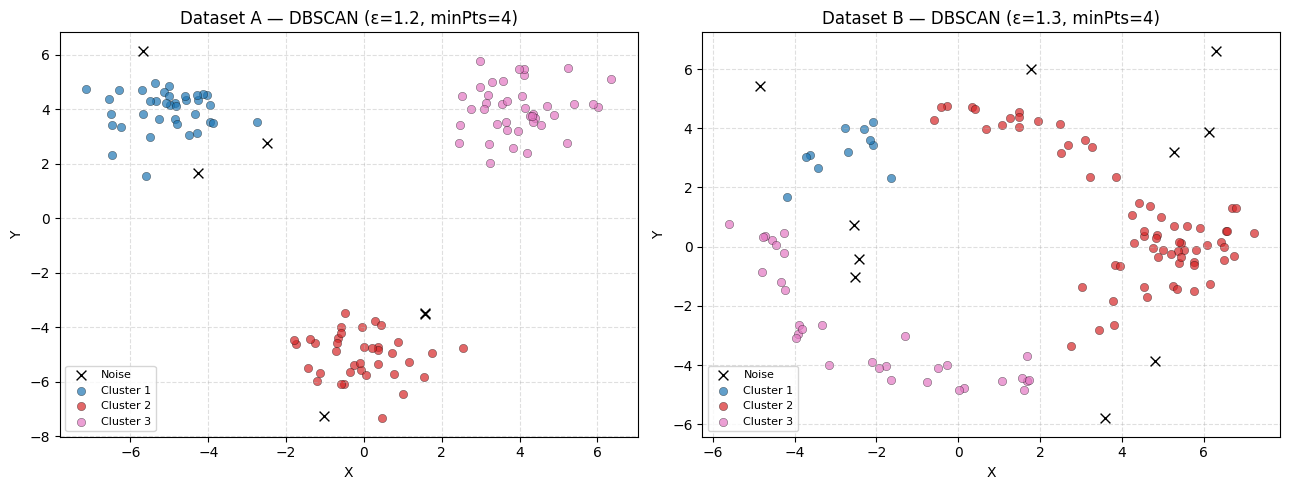

In [13]:
#DBSCAN Result Plots
def plot_dbscan(ax, data, labels, title):
    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap('tab10', max(max(labels)+1, 1))
    for lbl in unique_labels:
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(data[mask, 0], data[mask, 1], c='black', marker='x',
                       s=50, linewidths=1, label='Noise', zorder=5)
        else:
            ax.scatter(data[mask, 0], data[mask, 1], color=cmap(lbl-1),
                       alpha=0.7, edgecolors='k', linewidths=0.3,
                       label=f'Cluster {lbl}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_dbscan(axes[0], dataset_a, labels_a, f"Dataset A — DBSCAN (ε={eps_a}, minPts=4)")
plot_dbscan(axes[1], dataset_b, labels_b, f"Dataset B — DBSCAN (ε={eps_b}, minPts=4)")
plt.tight_layout()
plt.savefig("task3_dbscan.png", dpi=120)
plt.show()


---
## Task 4 — Comparison and Analysis

### Part A — Manual Silhouette Score


In [14]:
def manual_silhouette(data, labels):
    """
    Compute the mean Silhouette Score manually.

    For DBSCAN results, noise points (label == -1) are excluded.
    If a cluster contains only one point, its silhouette score is 0.
    """
    # Exclude noise points
    mask = labels != -1
    fd   = data[mask]    # filtered data
    fl   = labels[mask]  # filtered labels

    n = fd.shape[0]
    if n <= 1:
        return 0.0

    unique = np.unique(fl)
    if len(unique) < 2:
        return 0.0   # cannot compute with only one cluster

    scores = []

    for i in range(n):
        # a(i): mean distance to all other points in the same cluster
        same_idx = np.where(fl == fl[i])[0]
        same_idx = same_idx[same_idx != i]   # exclude self

        if len(same_idx) == 0:
            a_i = 0.0   # singleton cluster
        else:
            a_i = float(np.mean(
                np.sqrt(np.sum((fd[same_idx] - fd[i])**2, axis=1))
            ))

        # b(i): minimum mean distance to points in any OTHER cluster
        b_i = float('inf')
        for c in unique:
            if c == fl[i]:
                continue
            other = fd[fl == c]
            avg = float(np.mean(np.sqrt(np.sum((other - fd[i])**2, axis=1))))
            b_i = min(b_i, avg)

        # s(i) = (b(i) - a(i)) / max(a(i), b(i))
        denom = max(a_i, b_i)
        scores.append((b_i - a_i) / denom if denom > 0 else 0.0)

    return float(np.mean(scores))


sil_pa = manual_silhouette(dataset_a, assign_a)
sil_da = manual_silhouette(dataset_a, labels_a)
sil_pb = manual_silhouette(dataset_b, assign_b)
sil_db = manual_silhouette(dataset_b, labels_b)

print(f"Silhouette — Proto A: {sil_pa:.4f}   DBSCAN A: {sil_da:.4f}")
print(f"Silhouette — Proto B: {sil_pb:.4f}   DBSCAN B: {sil_db:.4f}")


Silhouette — Proto A: 0.8148   DBSCAN A: 0.8277
Silhouette — Proto B: 0.4733   DBSCAN B: 0.4371


In [15]:
#Comparison Table
header = f"{'Dataset':<9}{'Algorithm':<22}{'Clusters':<11}{'Noise':<9}{'Final SSE':<14}{'Silhouette'}"
sep    = "-" * 72

rows = [
    ("A", "Manual Prototype", 3,    0,    f"{sse_a[-1]:.2f}", f"{sil_pa:.4f}"),
    ("A", "DBSCAN",           nc_a, nn_a, "N/A",              f"{sil_da:.4f}"),
    ("B", "Manual Prototype", 2,    0,    f"{sse_b[-1]:.2f}", f"{sil_pb:.4f}"),
    ("B", "DBSCAN",           nc_b, nn_b, "N/A",              f"{sil_db:.4f}"),
]

print(header)
print(sep)
for ds, alg, nc, nn, sse, sil in rows:
    print(f"{ds:<9}{alg:<22}{nc:<11}{nn:<9}{sse:<14}{sil}")


Dataset  Algorithm             Clusters   Noise    Final SSE     Silhouette
------------------------------------------------------------------------
A        Manual Prototype      3          0        215.39        0.8148
A        DBSCAN                3          6        N/A           0.8277
B        Manual Prototype      2          0        1429.79       0.4733
B        DBSCAN                3          10       N/A           0.4371
